# Week 13 - Convolutions

ANN are quite powerful, but their scope is limited to tabular (vector) data. Many researchers wanted to figure out a way to apply them to more "interesting" data, notably images. Early attempts would "unravel" 2D images into 1D vectors. This could work for very simple cases, but not for anything especially interesting. In an image, the relation of pixels to their neighbours encodes interesting information, which is lost when you simply unravel it into 1D.

This notebook explores a technique to apply ML to images known as the "convolution".

But first, let's explore some basic image manipulation.

For this we will use a library called "opencv".

*Note: There are lots of different libraries for image handling. OpenCV is in no way the single "best" choice, but it is a simple one which is fairly user friendly.*

In [118]:
# Install opencv

%pip install opencv-python

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [119]:
# Let's read in a simple 16x16 RGB image

import cv2
import numpy as np

# img will be a numpy array
img = cv2.imread("mario.png")

# Let's check the shape:
img.shape

(16, 16, 3)

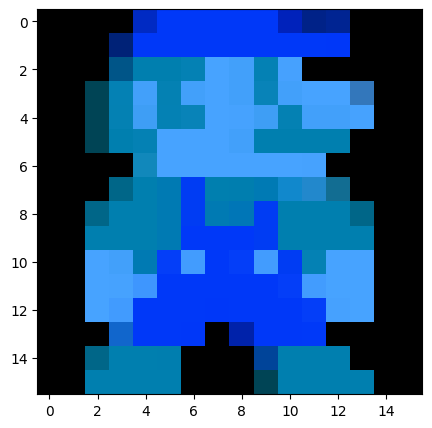

In [120]:
# Let's take a look at the image

import matplotlib.pyplot as plt

# This adjust the viewer side in the notebook:
plt.rcParams['figure.figsize'] = [5,5]

plt.imshow(img)

Why are the colours inverted? This is a silly mismatch where a png image is stored as RGB but opencv expectes the image to be BGR. It is fixable by flipping the RGB "dimension" of the numpy array:

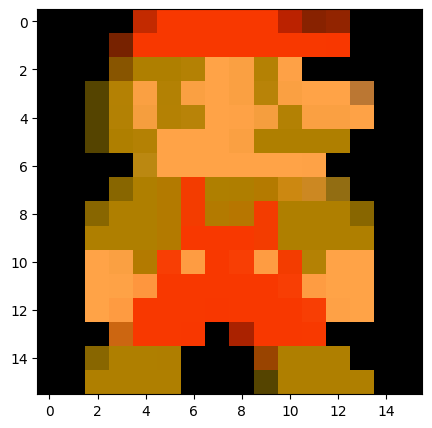

In [121]:
img = cv2.imread("mario.png")[:,:,::-1]
plt.imshow(img)

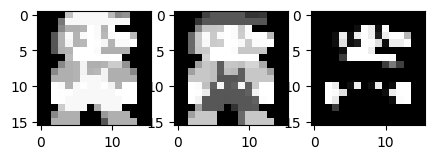

In [122]:
# We can check the individual colour channels separately:

f, ax = plt.subplots(1,3)
im1 = ax[0].imshow(img[:,:,0], cmap='gray')  # This is the red (R) channel
im2 = ax[1].imshow(img[:,:,1], cmap='gray')  # This is the green (G) channel
im2 = ax[2].imshow(img[:,:,2], cmap='gray')  # This is the blue (B) channel

# Note, as expected, the red sections of mario clothes are the "brightest" in the R channel

### General Image Manipulation

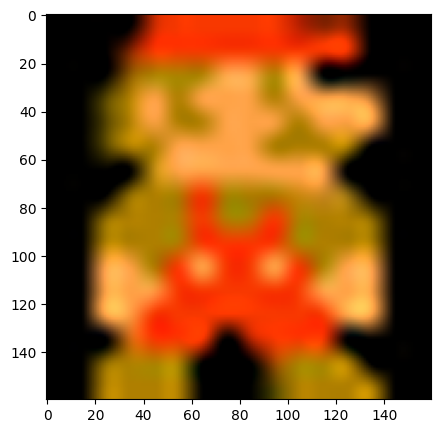

In [123]:
# We can shrink or blow-up the image:

res = cv2.resize(img, dsize=None, fx=10, fy=10, interpolation = cv2.INTER_CUBIC)

# dsize = destination size
# fx and fy are scaling factors (which can be used instead of providing a destination size). Here we blow-up by a factor of 10
# Interpolation is how we want to infer the values of pixels in the larger image

plt.imshow(res)

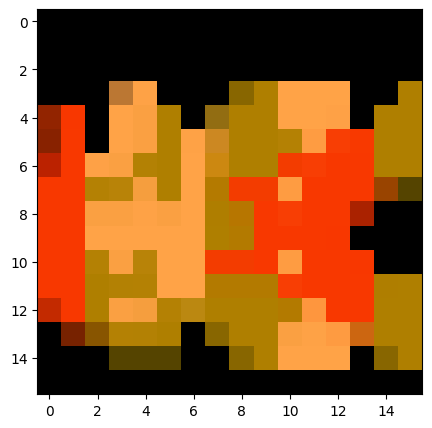

In [124]:
# We can rotate the image

import numpy as np

# Get the image dimensions
height, width = img.shape[:2]
 
# Define the rotation center (right in the middle)
center = (width // 2, height // 2)
 
# Get the rotation matrix
rotation_matrix = cv2.getRotationMatrix2D(center=center, angle=90, scale=1.0)
 
# Perform the rotation
rotated_image = cv2.warpAffine(img, rotation_matrix, (width, height))
 
# Display the result
plt.imshow(rotated_image)
 

In [125]:
# We can save our manipulated image to a new file

cv2.imwrite('rotated_mario.png', rotated_image)

True

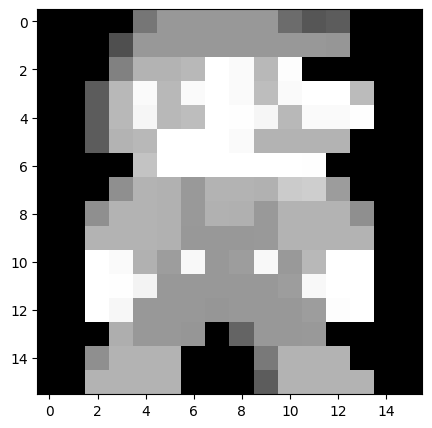

In [126]:
# We can make our image black and white

img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

plt.imshow(img_gray, cmap='gray')

In [127]:
# Notice the black and white image now has no 3rd dimension for colour

img_gray.shape

(16, 16)

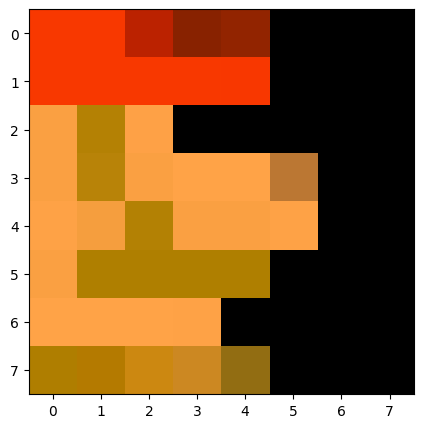

In [128]:
# We can also crop a smaller image from our full image (This will be really important!)

crop = img[0:8,8:16]
plt.imshow(crop)

### Convolutions

A convolution is a technique to "summarize" what is inside each region of an image.

Firstly a small "kernel" (K) must be defined. This is a small matrix (for mathematical reasons, usually $3\times3$ or $5\times5$) which will be repeatedly multiplied by small "crops" of the larger image (I). **Note:** This is broadcasting multiplication, not dot product!

Once the kernel and crop are multiplied, we take the sum of all the values, and then move the kernel to the next region and repeat. Each repetition results in an entry of a new matrix called the "convolved matrix" (or $I*K$).

Note that, in the general case, the size of the new matrix is smaller than the initial image. We will see more about this later.

Let's try!

<div>
<img src="./Convolution.png" width="600"/>
</div>
Source: https://tex.stackexchange.com/questions/437007/drawing-a-convolution-with-tikz

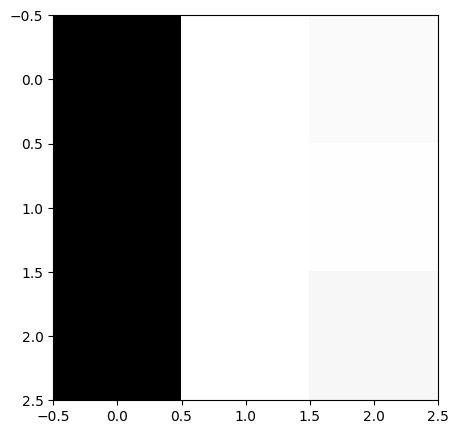

In [129]:
# Let's first start by taking a small section of our larger grayscale image (Mario's hand).
# Note: We take this specific region because it will show an interesting property - stay tuned!

crop = img_gray[10:13,1:4]
plt.imshow(crop, cmap='gray')

-153.13504672223146


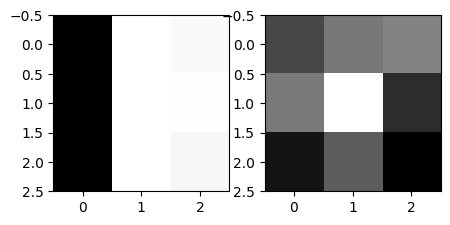

In [130]:
# Let's convolve with a random 3x3 kernel (with entries between -1 and 1) and see the final value

rand_kernel = np.random.uniform(-1,1,(3,3))  # Make a random kernel
conv = np.sum(rand_kernel*crop)  # This is the convolution
print(conv)

# We can also compare the intial crop with the random image:

f, ax = plt.subplots(1,2)
im1 = ax[0].imshow(crop, cmap='gray')
im2 = ax[1].imshow(rand_kernel, cmap='gray')

529


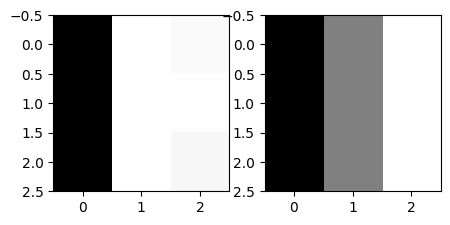

In [131]:
# Now let's do something a bit different. Let's make a custom kernel:

kernel = np.array(
    [[-1,0,1],
     [-1,0,1],
     [-1,0,1]]
     )

print(np.sum(kernel * crop))  # This is the convolution

f, ax = plt.subplots(1,2)
im1 = ax[0].imshow(crop, cmap='gray')
im2 = ax[1].imshow(kernel, cmap='gray')

-529


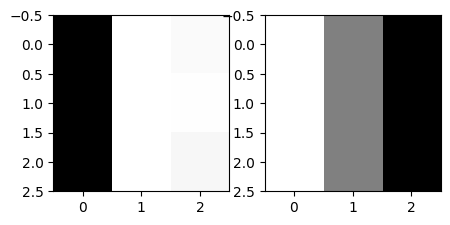

In [132]:
 # Let's try another version, this time with the kernel inverted:

kernel = np.array(
    [[1,0,-1],
     [1,0,-1],
     [1,0,-1]]
    )

print(np.sum(kernel * crop))   # This is the convolution

f, ax = plt.subplots(1,2)
im1 = ax[0].imshow(crop, cmap='gray')
im2 = ax[1].imshow(kernel, cmap='gray')

### Can you guess what these custom kernels do?

Answer: They are edge detectors! They give larger values when they encounter an edge. The first one looks for an edge where the darker pixels are on the left, the second one looks for an edge where the darker pixels are on the right. Notice the second one is very negative as it has encountered the inverse of what it is looking for.

### Convolving an entire photo

Now let's repeatedly apply this across an entire photo. We can have one loop to move the kernel horizontally one pixel at a time, and one loop to move the kernel vertically one pixel at a time.

In [133]:
def conv(img, kernel):

    # The resulting convolved image will be 2 pixels smaller 
    new_h = img.shape[0] - 2
    new_w = img.shape[1] - 2

    # We will initialize a new matrix within which the convolved entries will be stored (right now it is full of only zeros)
    convolved_img = np.zeros((new_h, new_w))

    # Now we loop over each entry in our new matrix
    for i in range(new_h):
        for j in range(new_w):
            crop = img[i:i+3,j:j+3]  # Take a 3x3 crop starting at the current pixel
            convolution = np.sum(kernel * crop)  # Convolution
            convolved_img[i,j] = convolution  # Save the convolution into our new array
    
    return convolved_img

convolved_img = conv(img_gray, kernel)

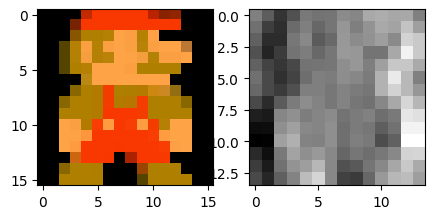

In [134]:
# Let's see the result!

f, ax = plt.subplots(1,2)
im1 = ax[0].imshow(img)
im2 = ax[1].imshow(convolved_img, cmap='gray')

### More complex convolutions

Let's first start working with a larger image

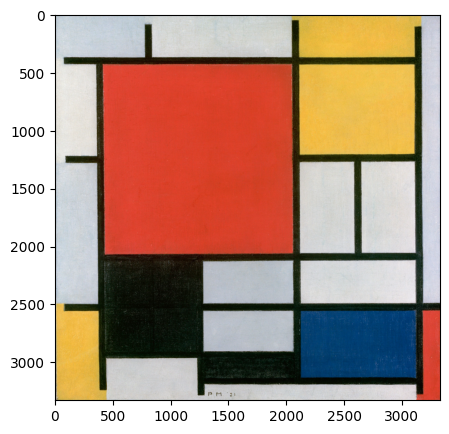

In [135]:
img = cv2.imread("art.png")[:,:,::-1]
plt.imshow(img)

### Repeating exactly the same steps

In [136]:
img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

In [137]:
# This may take some time (we need to complete about 80,000,000 multiplications)

convolved_img = conv(img_gray, kernel)

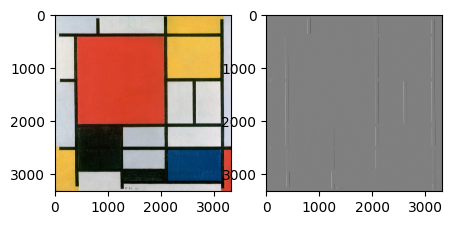

In [138]:
f, ax = plt.subplots(1,2)
im1 = ax[0].imshow(img)
im2 = ax[1].imshow(convolved_img, cmap='gray')

# Exercises

### Exercise 1.1

Let's start off with something easy. The following kernel can be used to blur images:

$$ \begin{bmatrix} 1 & 2 & 1 \\ 2 & 4 & 2 \\ 1 & 2 & 1 \end{bmatrix}$$

Define an array representing this kernel and apply it to the painting (in black and white). Compare the original and convolved image.

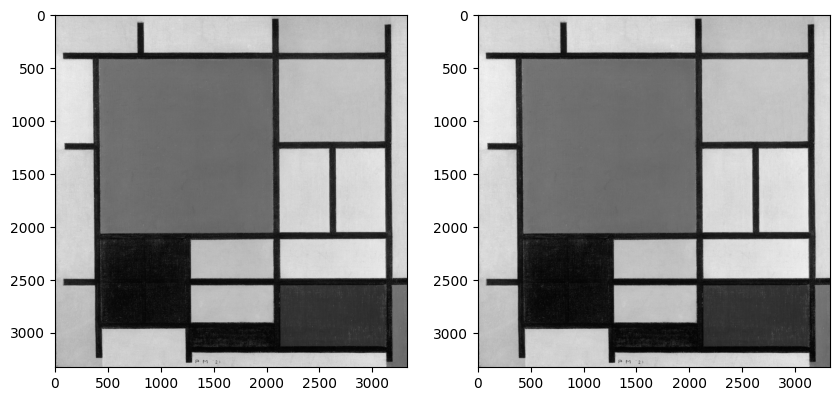

In [139]:
kernel = [
    [1,2,1],
    [2,4,2],
    [1,2,1]
]

convolved_img = conv(img_gray, kernel)

plt.rcParams['figure.figsize'] = [10,10]

f, ax = plt.subplots(1,2)
im1 = ax[0].imshow(img_gray, cmap='gray')
im2 = ax[1].imshow(convolved_img, cmap='gray')

### Exercise 1.2

Maybe surprisingly there appears to be no difference 🤔 This is because we are using a miniscule $3\times3$ kernel on a massive $3000\times3000$ image. If we zoom in, indeed we do see that the convolution has caused a slight blur.

Check the following range for both the initial image and convolved image side-by-side: [3100:3220,3000:3100]

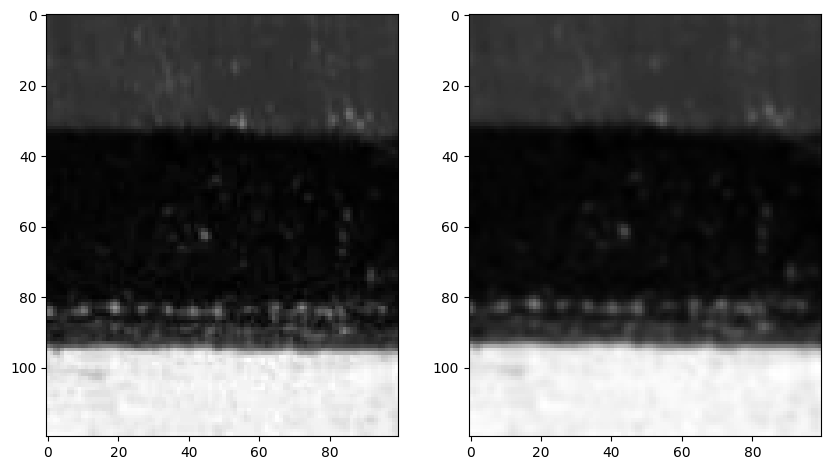

In [140]:
f, ax = plt.subplots(1,2)
im2 = ax[0].imshow(img_gray[3100:3220,3000:3100], cmap='gray')
im2 = ax[1].imshow(convolved_img[3100:3220,3000:3100], cmap='gray')

### Exercise 1.3

Although huge images can be nice for decorating one's wall, there is not really a need to have such a big image for most ML computer vision applications (classification, object detection). Think about how you can still identify and study the image even if it's much smaller.

Here, downsize the image to $256\times256$ (this is a common standard for ML on images) and then apply the same convolution and compare again. Now the blur should be visible.

In [141]:
img_gray = cv2.resize(img_gray, dsize=(256,256), interpolation = cv2.INTER_CUBIC)

In [142]:
convolved_img = conv(img_gray, kernel)

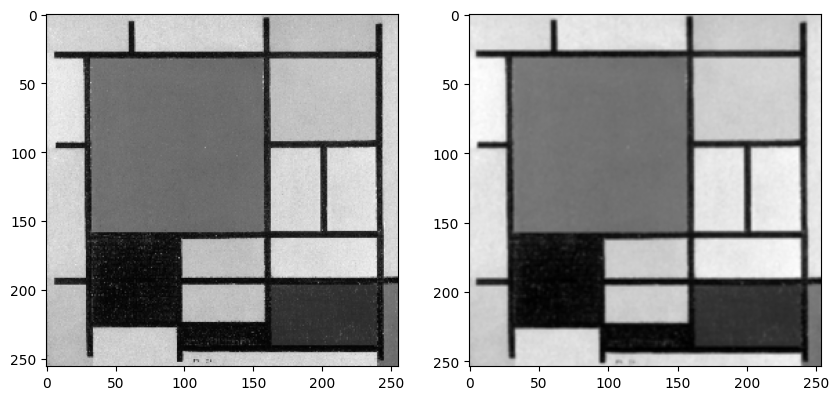

In [143]:
f, ax = plt.subplots(1,2)
im1 = ax[0].imshow(img_gray, cmap='gray')
im2 = ax[1].imshow(convolved_img, cmap='gray')

### Exercise 2

Remember that the application of a convolution to a region of an image is effectively "studying" that region of the image. With this in mind, it's not really necessary to study *every* region. Very often, the kernel is slid over 2 pixels (or more) at a time. This is called the "stride". This still provides a good summary of the image. It also has the effect of shrinking the image by a factor equal to the stride (ie. if stride=3 then the image will be 3 times smaller). In fact, this turns out to be a good thing (more about this to come in the next exercise...)

Here we will rework the convoultion function to also take a stride. In fact, only 3 lines have to be changed.

Test the function with a stride of 2 and view the results. Note the change in size.

In [ ]:
def conv_with_stride(img, kernel, stride):

    # The resulting convolved image will be 2 pixels smaller 
    new_h = img.shape[0]//stride - 2
    new_w = img.shape[1]//stride - 2

    # We will initialize a new matrix within which the convolved entries will be stored (right now it is full of only zeros)
    convolved_img = np.zeros((new_h, new_w))

    # Now we loop over each entry in our new matrix
    for i in range(0,new_h):
        for j in range(0,new_w):
            crop = img[i*stride:i*stride+3,j*stride:j*stride+3]  # Take a 3x3 crop starting at the current pixel
            convolution = np.sum(kernel * crop)  # Convolution
            convolved_img[i,j] = convolution  # Save the convolution into our new array
    
    return convolved_img

convolved_img = conv_with_stride(img_gray, kernel, 2)

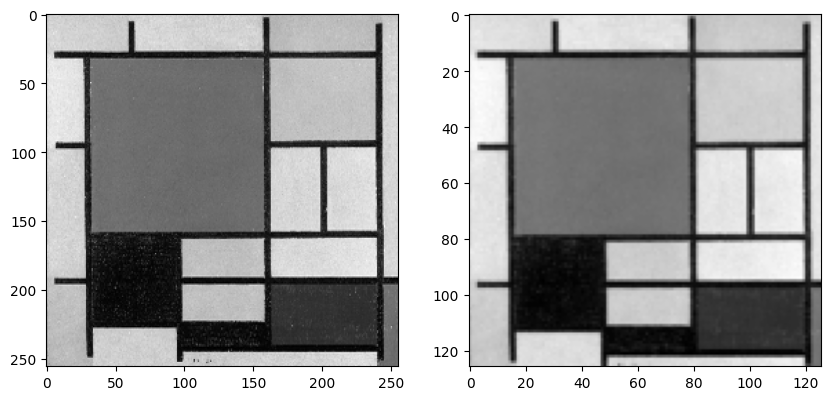

In [ ]:
f, ax = plt.subplots(1,2)
im1 = ax[0].imshow(img_gray, cmap='gray')
im2 = ax[1].imshow(convolved_img, cmap='gray')

### Exercise 3.1

Now for something crazy. It's actually possible to convolve an image with a 3D kernel.

A 3D kernel can be thought of as a stack of 2D kernels, where each one studies something different across the image.

For example, the first "slice" of the 3D kernel maybe looks for horizontal lines, the 2nd looks for vertical lines, etc.

So it's like we can apply a bunch of kernels to an image at the same time.

In this exercise we will see how this works.

Let's start by creating a 3D kernel consisting of four $3\times3$ kernels.

Use the following four $3\times3$ kernels:

* Vertical line detector (see above - we applied it to Mario's hand)
* Vertical line detector inverse version (see above - we applied it to Mario's hand)
* Horizontal line detector
* Horizontal line detector

You may need to look online at "how to create a 3D numpy array".

Check that your output is the correct shape using kernel.shape (it should return (4,3,3))

In [ ]:
kernel = np.array([
    [
        [1,0,-1],
        [1,0,-1],
        [1,0,-1]
    ],
    [
        [-1,0,1],
        [-1,0,1],
        [-1,0,1]
    ],
    [
        [1,1,1],
        [0,0,0],
        [-1,-1,-1]
    ],
    [
        [-1,-1,-1],
        [0,0,0],
        [1,1,1]
    ]
])

In [ ]:
kernel.shape

(4, 3, 3)

Now take a $3\times3$ crop from the top left of the grayscale image (shape = ($3\times3$)) and multiply this with the 3D kernel. What is the output like?

In [ ]:
M = img_gray[0:3,0:3]
M*kernel

Finally, we want to sum up the values, but only across each slice in order to have 4 distinct numbers (it's as if we had applied 4 kernels seperately in order to arrive at 4 different convolved values).

If we simply used np.sum with no arguments it would sum all numbers and we would only have a single result. Therefore, use np.sum with the argument "axis=(1,2)". This is because the 0th axis is the axis along which the kernels are "stacked" (you can see this by checking kernel[0,:,:] - you will see it's the simple vertical edge detector), so we only want to sum across the 1st and 2nd axes.

In [ ]:
np.sum(M*kernel, axis=(1,2))

array([ -5,   5, -30,  30])

We arrive at 4 convolutions with only a single multiplication. Fantastic!

### Exercise 3.2

If you've gotten this far, bravo!

As a final step, let's update our function to allow 3D kernel convolution. It only requires one small change!

In [ ]:
def conv_with_stride(img, kernel, stride):

    new_d = kernel.shape[0]  # To change: The convolved_img will now have depth. This can be infered by the depth of the kernel
    new_h = img.shape[0]//stride - 2
    new_w = img.shape[1]//stride - 2

    convolved_img = np.zeros((new_d, new_h, new_w))  # Here the new_d is already included

    for i in range(0,new_h):
        for j in range(0,new_w):
            crop = img[i*stride:i*stride+3,j*stride:j*stride+3]
            convolution = np.sum(kernel * crop, axis=(1,2))  # The axis argument is already included
            convolved_img[:,i,j] = convolution  # Here, instead of placing a single convolution value, we have a convolution "vector"
                                                # So we place it along the entire depth using the ":", which is already done
    
    return convolved_img

convolved_img = conv_with_stride(img_gray, kernel, 2)

In [ ]:
convolved_img.shape

(4, 126, 126)

Finally we can plot the original image and the 4 convolved images. You can see that we have successfully applied 4 kernels in a single step.

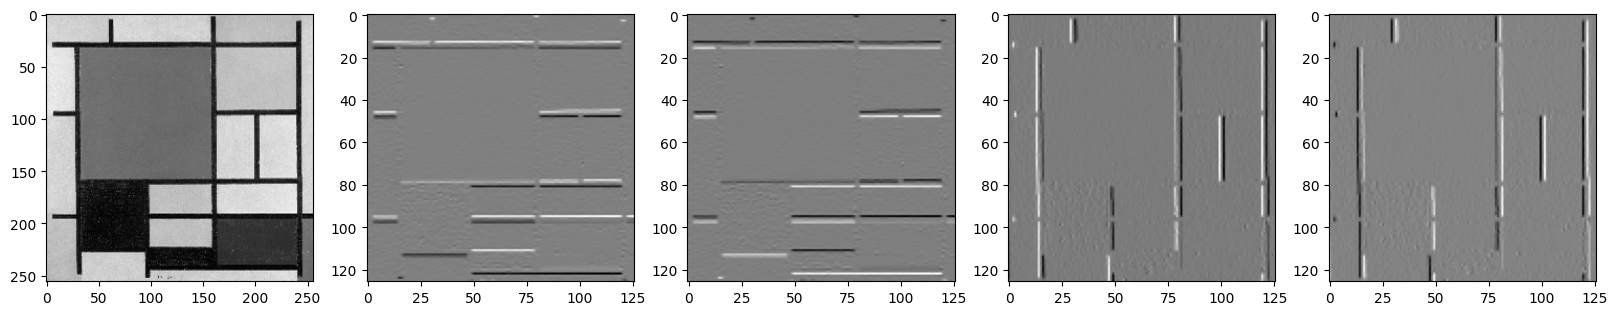

In [ ]:
plt.rcParams['figure.figsize'] = [20,30]

f, ax = plt.subplots(1,5)
im1 = ax[0].imshow(img_gray, cmap='gray')
im2 = ax[1].imshow(convolved_img[0,:,:], cmap='gray')
im3 = ax[2].imshow(convolved_img[1,:,:], cmap='gray')
im3 = ax[3].imshow(convolved_img[2,:,:], cmap='gray')
im3 = ax[4].imshow(convolved_img[3,:,:], cmap='gray')

This is super computationally efficient. With a stride greater than 1 it also has the property of shrinking the image. If we kept doing this with stride 2 and kernels of size $2\times3\times3$ the size would go:

* Initial image: $256\times256$
* After 1st conv: $2\times128\times128$
* After 2nd conv: $4\times64\times64$
* After 3rd conv: $8\times32\times32$
* After 4th conv: $16\times16\times16$
* After 5th conv: $32\times8\times8$
* After 6th conv: $64\times4\times4$
* After 7th conv: $128\times2\times2$
* After 8th conv: $256\times1\times1$

And then we have just a 1D vector of length 256 which can be put into an ANN!

And so the mystery of how to use image date in ML has been solved. Hurray!